# Ad revenue: what moved it, and when to raise an alert

Walkthrough on top of the dbt models. Before running it, download the data and build the models:

```bash
python scripts/download_data.py
cd dbt && dbt build
```

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

con = duckdb.connect("../data/ad_revenue.duckdb", read_only=True)


def sql(query: str) -> pd.DataFrame:
    return con.sql(query).df()

## 1. Data overview

Revenue, impressions and eCPM of the publisher per day, June 2019.

In [2]:
daily = sql("""
    select
        report_date,
        sum(impressions)                                    as impressions,
        sum(revenue)                                        as revenue,
        sum(revenue) * 1000 / nullif(sum(impressions), 0)   as ecpm
    from fct_ad_delivery_daily
    group by report_date
    order by report_date
""")
daily

,report_date,impressions,revenue,ecpm
0,2019-06-01,486756.0,1086.5420,2.232211
1,2019-06-02,636942.0,1338.1880,2.100957
2,2019-06-03,712014.0,1556.1432,2.185551
3,2019-06-04,581034.0,1291.0508,2.221988
4,2019-06-05,527132.0,1143.2104,2.168736
5,2019-06-06,730188.0,1479.0596,2.025587
6,2019-06-07,625676.0,1283.5674,2.051489
7,2019-06-08,502832.0,1007.7296,2.004108
8,2019-06-09,684146.0,1297.3322,1.896280
9,2019-06-10,724370.0,1352.2488,1.866793


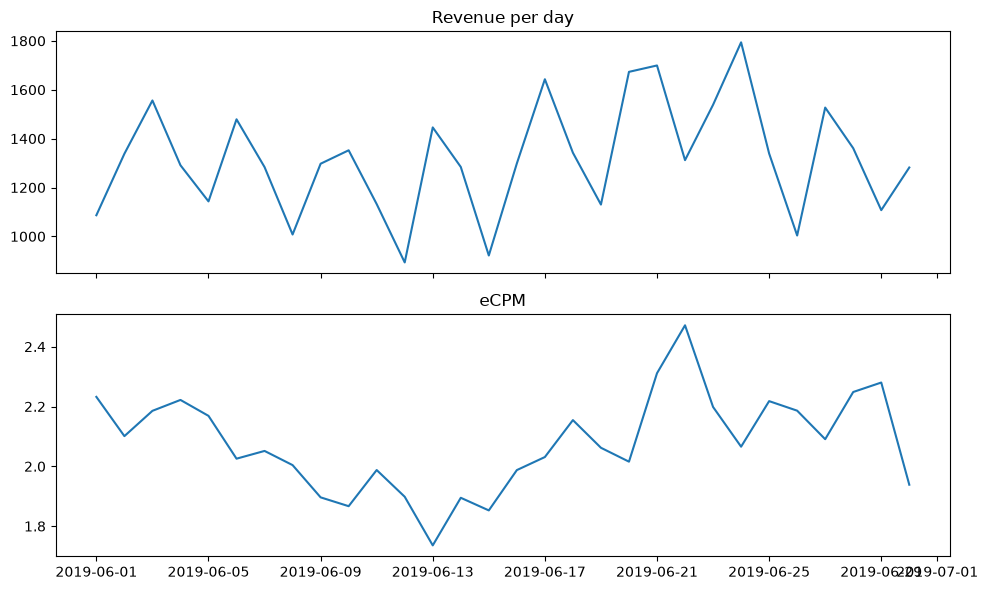

In [3]:
fig, (ax_revenue, ax_ecpm) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax_revenue.plot(daily["report_date"], daily["revenue"])
ax_revenue.set_title("Revenue per day")
ax_ecpm.plot(daily["report_date"], daily["ecpm"])
ax_ecpm.set_title("eCPM")
fig.tight_layout()

## 2. Data quality findings

Profiling the source turned up a row grain finer than the columns, a third of rows without delivery, one negative-revenue
adjustment and some viewability inconsistencies. The findings and the decision taken for each are in the README
(*Data quality findings*); the ones that can recur are `warn`-level dbt tests, so `dbt build` reports them on every run.

## 3. What moved revenue

`mart_revenue_change_drivers` compares every day with the average of the same weekday over the previous 2–3 weeks
and splits the change of each slice into a volume effect (impressions) and a price effect (eCPM).

### Why a same-weekday baseline

Delivery has a strong weekly pattern, so a trailing 7-day average turns every Wednesday into a drop and every Monday
into a spike. `int_delivery__vs_baseline` keeps the trailing average as a reference column, so both baselines can be
scored on the same days: WAPE is the total absolute miss as a share of actual revenue.

In [4]:
sql("""
    select
        dayname(report_date)    as weekday,
        avg(impressions)        as avg_impressions
    from int_delivery__by_dimension_daily
    where dimension = 'total'
    group by weekday, isodow(report_date)
    order by isodow(report_date)
""").round(0)

,weekday,avg_impressions
0,Monday,778438.0
1,Tuesday,594354.0
2,Wednesday,501250.0
3,Thursday,780937.0
4,Friday,660946.0
5,Saturday,500734.0
6,Sunday,667079.0


In [5]:
sql("""
    select
        dimension,
        100 * sum(abs(revenue - trailing_7d_revenue)) / sum(revenue)  as trailing_7d_wape,
        100 * sum(abs(revenue - baseline_revenue)) / sum(revenue)     as same_weekday_wape
    from int_delivery__vs_baseline
    group by dimension
    order by same_weekday_wape
""").round(1)

,dimension,trailing_7d_wape,same_weekday_wape
0,total,16.0,10.6
1,ad_type_id,16.4,10.9
2,device_category_id,16.9,11.4
3,os_id,17.3,11.8
4,geo_id,17.6,12.5
5,monetization_channel_id,16.6,12.8
6,advertiser_id,18.0,14.7
7,site_id,21.6,17.7
8,ad_unit_id,27.5,27.4


### Top drivers of the largest change

The day with the largest change against its baseline and the top three slices of each dimension behind it.

In [6]:
biggest_change = sql("""
    select report_date, revenue_delta
    from mart_revenue_change_drivers
    where dimension = 'total'
    order by abs(revenue_delta) desc
    limit 1
""")
day = biggest_change["report_date"].iloc[0]

sql(f"""
    select dimension, dimension_value, revenue_delta, volume_effect, price_effect, share_of_total_delta
    from mart_revenue_change_drivers
    where report_date = '{day}'
      and dimension <> 'total'
      and driver_rank <= 3
    order by dimension, driver_rank
""")

,dimension,dimension_value,revenue_delta,volume_effect,price_effect,share_of_total_delta
0,ad_type_id,10,381.0426,167.405678,213.636922,0.917153
1,ad_type_id,17,34.4200,10.540541,23.879459,0.082847
2,ad_unit_id,5100,71.2956,49.944258,21.351342,0.171605
3,ad_unit_id,5097,51.5243,51.565023,-0.040723,0.124017
4,ad_unit_id,5101,47.9803,29.778900,18.201400,0.115486
5,advertiser_id,79,312.3227,136.646616,175.676084,0.751747
6,advertiser_id,16,50.8169,13.742234,37.074666,0.122314
7,advertiser_id,8,25.3790,24.879998,0.499002,0.061086
8,device_category_id,1,188.9686,48.304146,140.664454,0.454839
9,device_category_id,2,159.8959,89.084866,70.811034,0.384862


### Case study: 21–22 June

Friday 21 and Saturday 22 June are the two largest changes of the month. Three questions:
was it more traffic, traffic moving to better-paid inventory, or the same inventory paid more?
Where did it happen? And how broad was it?

`mart_revenue_change_daily` answers the first one: it splits each day's change at the finest grain into
**traffic** (more impressions overall), **mix** (impressions moving between slices with different eCPM)
and **rate** (the same slice paid differently).

In [7]:
sql("""
    select
        report_date,
        dayname(report_date)                    as weekday,
        revenue,
        baseline_revenue,
        100 * revenue_delta / baseline_revenue  as change_pct,
        traffic_effect,
        mix_effect,
        rate_effect
    from mart_revenue_change_daily
    where report_date between '2019-06-19' and '2019-06-24'
    order by report_date
""").round(1)

C:\Users\music\AppData\Local\Temp\ipykernel_19928\1225002368.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  """).round(1)


,report_date,weekday,revenue,baseline_revenue,change_pct,traffic_effect,mix_effect,rate_effect
0,2019-06-19,Wednesday,1130.2,1018.3,11.0,100.9,45.8,-34.9
1,2019-06-20,Thursday,1673.2,1462.5,14.4,94.3,176.2,-59.8
2,2019-06-21,Friday,1699.3,1283.8,32.4,178.9,103.2,133.4
3,2019-06-22,Saturday,1312.0,1005.4,30.5,79.0,35.2,192.4
4,2019-06-23,Sunday,1538.4,1311.3,17.3,87.2,31.0,108.8
5,2019-06-24,Monday,1794.0,1517.1,18.2,245.6,55.1,-23.9


On Friday the change is spread across all three effects; on Saturday the rate effect is almost two thirds of it.
The drivers above point at site 345 for the extra impressions and at advertiser 79, geo 187 and channel 19 for the price.

#### Traffic and mix: a surge on an expensive site

In [8]:
sql("""
    select
        report_date,
        dayname(report_date)                        as weekday,
        sum(impressions)                            as impressions,
        sum(revenue) * 1000 / sum(impressions)      as ecpm
    from fct_ad_delivery_daily
    where site_id = 345
      and report_date between '2019-06-10' and '2019-06-28'
    group by report_date
    order by report_date
""").round(2)

C:\Users\music\AppData\Local\Temp\ipykernel_19928\3967724049.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  """).round(2)


,report_date,weekday,impressions,ecpm
0,2019-06-10,Monday,73616.0,2.21
1,2019-06-11,Tuesday,53928.0,2.26
2,2019-06-12,Wednesday,42154.0,2.22
3,2019-06-13,Thursday,66568.0,2.27
4,2019-06-14,Friday,61338.0,2.51
5,2019-06-15,Saturday,41118.0,2.34
6,2019-06-16,Sunday,60536.0,2.26
7,2019-06-17,Monday,92804.0,2.36
8,2019-06-18,Tuesday,56494.0,2.47
9,2019-06-19,Wednesday,49972.0,2.43


Site 345 earns one of the highest eCPMs (2.55 for the month against 2.07 overall). Its traffic rose from 17 to
25 June and peaked on Friday 21 June at 146K impressions, 2.1× its same-weekday baseline. More impressions on
expensive inventory shows up as both traffic and mix.

#### Rate: the main buyer paid more, everywhere

Advertiser 79 brings 73% of revenue, all of it through channel 19. Its eCPM on Fridays and Saturdays:

In [9]:
sql("""
    select
        report_date,
        dayname(report_date)                        as weekday,
        sum(revenue) * 1000 / sum(impressions)      as ecpm
    from fct_ad_delivery_daily
    where advertiser_id = 79
      and dayname(report_date) in ('Friday', 'Saturday')
    group by report_date
    order by weekday, report_date
""").round(2)

C:\Users\music\AppData\Local\Temp\ipykernel_19928\2422511742.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  """).round(2)


,report_date,weekday,ecpm
0,2019-06-07,Friday,2.24
1,2019-06-14,Friday,1.96
2,2019-06-21,Friday,2.46
3,2019-06-28,Friday,2.21
4,2019-06-01,Saturday,2.36
5,2019-06-08,Saturday,2.16
6,2019-06-15,Saturday,1.90
7,2019-06-22,Saturday,2.68
8,2019-06-29,Saturday,2.28


Both event days are the highest eCPM of their weekday in the month. To tell a demand-side change (the buyer bids
more) from a publisher-side one (a new floor price or placement on some sites), compare the buyer's eCPM on the
event days with the baseline days, slice by slice:

In [10]:
EVENT_DAYS = ("2019-06-21", "2019-06-22")
BASELINE_DAYS = ("2019-06-07", "2019-06-14", "2019-06-01", "2019-06-08", "2019-06-15")


def main_buyer_ecpm_change(dimension: str, min_baseline_impressions: int = 20_000) -> pd.DataFrame:
    """eCPM of advertiser 79 on the event days vs their same-weekday baseline days, per slice."""
    return sql(f"""
        with periods as (
            select
                {dimension},
                report_date in {EVENT_DAYS}     as is_event,
                impressions,
                revenue
            from fct_ad_delivery_daily
            where advertiser_id = 79
              and report_date in {EVENT_DAYS + BASELINE_DAYS}
        ),

        by_slice as (
            select
                {dimension},
                sum(impressions) filter (where not is_event)                                            as baseline_impressions,
                sum(revenue) filter (where not is_event) * 1000 / sum(impressions) filter (where not is_event)  as baseline_ecpm,
                sum(revenue) filter (where is_event) * 1000 / sum(impressions) filter (where is_event)          as event_ecpm
            from periods
            group by {dimension}
        )

        select *, 100 * (event_ecpm / baseline_ecpm - 1) as ecpm_change_pct
        from by_slice
        where baseline_impressions >= {min_baseline_impressions}
        order by baseline_impressions desc
    """).round(2)


main_buyer_ecpm_change("site_id")

,site_id,baseline_impressions,baseline_ecpm,event_ecpm,ecpm_change_pct
0,350,463074.0,1.09,1.20,9.82
1,349,374510.0,2.40,2.32,-3.20
2,346,249980.0,2.06,2.51,22.06
3,343,248274.0,2.36,2.88,22.03
4,351,204292.0,2.34,2.59,10.75
5,345,201124.0,3.13,3.93,25.60
6,344,121670.0,2.20,3.07,39.40
7,342,81964.0,3.05,3.33,9.09


In [11]:
main_buyer_ecpm_change("device_category_id")

,device_category_id,baseline_impressions,baseline_ecpm,event_ecpm,ecpm_change_pct
0,2,870048.0,1.81,2.01,10.87
1,1,722880.0,2.83,3.51,23.98
2,3,352294.0,1.44,1.97,36.92


In [12]:
main_buyer_ecpm_change("geo_id")

,geo_id,baseline_impressions,baseline_ecpm,event_ecpm,ecpm_change_pct
0,187,1575578.0,2.25,2.70,19.74
1,33,153890.0,1.88,2.30,22.05
2,11,80502.0,1.82,2.11,15.79
3,183,45544.0,1.42,2.22,56.55


**What happened on 21–22 June**

- Revenue was **+32% on Friday and +30% on Saturday** against the same weekdays of previous weeks, the two largest
  changes of the month. Two things coincided:
  1. **A traffic surge on an expensive site.** Site 345 had 2.1× its usual Friday traffic. Traffic and mix effects
     add up to +282 of the +415 on Friday.
  2. **The main buyer paid more for the same inventory.** Advertiser 79 raised its eCPM by ~20% (2.12 → 2.55),
     on 7 of its 8 large sites, on all three main device types and in every large geo. Rate effect: +133 on Friday,
     +192 on Saturday.
- Both faded by 23–24 June.
- The breadth points to the demand side: a publisher-side change (a new floor price, a new placement) would show up
  on particular sites or ad units, not everywhere at once. *Why* the buyer paid more (a campaign, end-of-quarter
  budgets, a change in bid shading) cannot be told from revenue-level data.
- Caveat: the baseline weeks include a mid-June eCPM dip (the week of 10 June averaged 1.88 against 2.08 the week
  before), so part of the rate effect is a rebound. Even so, both days are the main buyer's highest eCPM for their
  weekday in the whole month.

## 4. Anomaly detectors on labelled ad exchange data

The NAB series come with hand-labelled anomaly windows, so detectors can be scored instead of judged by eye.
The detectors live in [`src/detection.py`](../src/detection.py) (unit-tested in `tests/`). All of them are causal:
an hour's score uses only earlier hours, as a live alert would.

| Detector | Score |
|---|---|
| rolling z-score | distance from the mean of the previous *window* hours, in standard deviations |
| robust z-score | the same with median and MAD, so past spikes do not inflate the scale |
| seasonal z-score | distance from the median of the same hour over the previous *days*, robustly scaled |
| level shift | mean of the last *recent* hours against the *window* before them; catches sustained shifts |

An alert fires when |score| exceeds a threshold; alerts less than 3 hours apart form one alert event.
**Precision** is the share of alert events that overlap a labelled window, **recall** the share of windows with
at least one alert.

In [13]:
import sys

sys.path.insert(0, "../src")
from detection import DETECTORS, THRESHOLDS, cross_validate, grid_counts, summarise

metrics = sql("select * from fct_exchange_metrics_hourly")
windows = sql("select * from stg_nab__anomaly_windows")

windows.assign(hours=(windows.window_end - windows.window_start).dt.total_seconds() / 3600)

,exchange,metric,window_start,window_end,hours
0,exchange-2,CPC,2011-07-11 04:00:01,2011-07-17 22:00:01,162.0
1,exchange-2,CPM,2011-07-24 14:00:01,2011-07-27 22:00:01,80.0
2,exchange-2,CPM,2011-08-09 00:00:01,2011-08-12 09:00:01,81.0
3,exchange-3,CPC,2011-07-13 09:15:01,2011-07-15 11:15:01,50.0
4,exchange-3,CPC,2011-07-19 09:15:01,2011-07-21 11:15:01,50.0
5,exchange-3,CPC,2011-08-12 07:15:01,2011-08-14 13:15:01,54.0
6,exchange-3,CPM,2011-08-16 10:15:01,2011-08-23 00:15:01,158.0
7,exchange-4,CPC,2011-07-15 06:15:01,2011-07-17 12:15:01,54.0
8,exchange-4,CPC,2011-08-01 07:15:01,2011-08-03 15:15:01,56.0
9,exchange-4,CPC,2011-08-22 05:15:01,2011-08-24 11:15:01,54.0


14 windows over 6 series, covering ~10% of all hours, so random alerts would land in a window about 10% of the
time: that is the precision to beat. The series differ a lot: exchange-2 is smooth with slow drifts, exchange-3 has
gaps of up to 16 hours, exchange-4 is spiky with single hours 30× the average.

In [14]:
metrics.groupby(["exchange", "metric"]).metric_value.describe().round(3)

count   mean    std    min    25%    50%    75%     max
exchange   metric                                                          
exchange-2 CPC     1623.0  0.102  0.034  0.027  0.077  0.101  0.124   0.227
           CPM     1623.0  0.336  0.162  0.000  0.208  0.295  0.456   1.051
exchange-3 CPC     1538.0  0.137  0.076  0.039  0.098  0.118  0.153   1.034
           CPM     1538.0  0.773  0.337  0.321  0.563  0.695  0.896   5.498
exchange-4 CPC     1643.0  0.086  0.129  0.024  0.055  0.073  0.095   3.127
           CPM     1643.0  0.534  0.747  0.122  0.360  0.468  0.584  16.438

### Choosing parameters without peeking

Each detector has a small grid of parameters and thresholds. To keep the score honest, parameters are chosen
**leaving one exchange out**: pick the combination with the best F1 on two exchanges, score it on the third,
repeat for each exchange and pool the held-out results.

In [15]:
counts = grid_counts(metrics, windows)
folds = cross_validate(counts)
folds[["held_out", "detector", "params", "threshold", "events", "true_events", "windows", "detected_windows"]]

,held_out,detector,params,threshold,events,true_events,windows,detected_windows
0,exchange-2,level shift,"{'recent': 12, 'window': 72}",10.0,0,0,3,0
1,exchange-2,robust z-score,{'window': 168},20.0,0,0,3,0
2,exchange-2,rolling z-score,{'window': 168},10.0,0,0,3,0
3,exchange-2,seasonal z-score,"{'days': 7, 'window': 168}",20.0,0,0,3,0
4,exchange-3,level shift,"{'recent': 12, 'window': 168}",8.0,2,2,4,1
5,exchange-3,robust z-score,{'window': 168},20.0,5,4,4,4
6,exchange-3,rolling z-score,{'window': 168},12.0,2,2,4,2
7,exchange-3,seasonal z-score,"{'days': 7, 'window': 168}",8.0,13,4,4,3
8,exchange-4,level shift,"{'recent': 6, 'window': 72}",10.0,12,5,7,5
9,exchange-4,robust z-score,{'window': 168},15.0,21,9,7,5


In [16]:
held_out = folds.groupby("detector").apply(lambda g: pd.Series(summarise(g)), include_groups=False)
held_out.sort_values("f1", ascending=False).round(2)

,precision,recall,f1,alert_events,false_events
detector,,,,,
robust z-score,0.50,0.64,0.56,26.0,13.0
rolling z-score,0.48,0.57,0.52,21.0,11.0
level shift,0.50,0.43,0.46,14.0,7.0
seasonal z-score,0.37,0.57,0.45,35.0,22.0


### What the numbers say

- **Every detector beats chance by a wide margin**: 37–50% of the alert events are real anomalies, against
  ~10% for random alerts, and 6–9 of the 14 windows are caught.
- **The differences between detectors are within noise.** With 14 windows, one window is 7 points of recall; the
  ranking changes when the grid changes by one step. Picking "the best detector" here would be overfitting.
- **The simple rolling z-score is the most stable choice**: the same one-week window wins in every fold. The robust
  z-score needs thresholds of 15–20, because the MAD of these heavy-tailed series is tiny, so its scores explode
  on ordinary spikes.
- **No detector catches exchange-2 (0 of 3 windows).** Its anomalies are slow 15–20% dips, and unlabelled dips of
  the same size happen nearby; detectors tuned on spiky series choose thresholds far above them. Different kinds
  of anomaly need different detectors and their own tuning.
- The labels are not perfect either: exchange-4 has an unlabelled one-hour CPM spike to 10 on 22 July that any
  detector flags.

The chart below is the held-out choice for exchange-4: rolling z-score over the previous week, threshold 6.

In [17]:
from detection import alert_events, score_series

example = score_series(metrics, "rolling z-score", {"window": 168})
example = example[(example.exchange == "exchange-4") & (example.metric == "CPM")].reset_index(drop=True)
example_alerts = example["score"].abs() > 6
alert_events(example["observed_at"], example_alerts)

,start,end
0,2011-07-11 00:15:01,2011-07-11 00:15:01
1,2011-07-16 09:15:01,2011-07-16 09:15:01
2,2011-07-16 14:15:01,2011-07-16 14:15:01
3,2011-07-22 12:15:01,2011-07-22 12:15:01
4,2011-07-22 16:15:01,2011-07-22 16:15:01
5,2011-08-02 18:15:01,2011-08-02 18:15:01
6,2011-08-02 23:15:01,2011-08-02 23:15:01
7,2011-08-21 09:15:01,2011-08-21 09:15:01
8,2011-08-23 08:15:01,2011-08-23 08:15:01
9,2011-08-28 13:15:01,2011-08-28 13:15:01


![Detection example](../output/detection_example_light.png)

## 5. Alerts on the publisher data

The publisher data is daily and has no labels, so the lessons from section 4 decide the design rather than a score:

- **different events need different rules**, so there are three: the *total* moving more than its usual noise,
  a material slice that *stopped delivering*, and a *large slice that moved*;
- **thresholds come from the noise**, not from a guess: a change has to exceed twice the same-weekday baseline's usual
  error (WAPE) for its dimension, so a noisy dimension (ad units, ~27%) needs a bigger move than a stable one
  (devices, ~11%);
- **materiality**: a slice must move at least 5% of the day's revenue (1% for a slice that stops), otherwise
  hundreds of small ad units would alert;
- **no repeats**: while the same rule keeps firing on the same slice, or fires again within 7 days, it stays quiet.

The rules live in the dbt model `mart_revenue_alerts` (thresholds are dbt vars), with a unit test for the rules and
the cooldown. Each alert carries its volume and price effects and a one-line explanation.

In [18]:
alerts = sql("""
    select report_date, rule, alert_text
    from mart_revenue_alerts
    order by report_date, rule desc, share_of_day_revenue desc
""")
alerts

,report_date,rule,alert_text
0,2019-06-15,stopped delivering,advertiser_id 2644: revenue -100% against the ...
1,2019-06-15,stopped delivering,ad_unit_id 5181: revenue -100% against the sam...
2,2019-06-15,stopped delivering,monetization_channel_id 21: revenue -100% agai...
3,2019-06-17,large slice moved,site_id 346: revenue +79% against the same wee...
4,2019-06-20,large slice moved,site_id 351: revenue +48% against the same wee...
5,2019-06-21,total revenue,total total: revenue +32% against the same wee...
6,2019-06-21,large slice moved,ad_type_id 10: revenue +30% against the same w...
7,2019-06-21,large slice moved,monetization_channel_id 19: revenue +33% again...
8,2019-06-21,large slice moved,geo_id 187: revenue +33% against the same week...
9,2019-06-21,large slice moved,advertiser_id 79: revenue +33% against the sam...


In [19]:
sql("""
    select
        report_date,
        dayname(report_date)                                    as weekday,
        count(*)                                                as alerts,
        string_agg(distinct rule, ', ')                         as rules,
        string_agg(dimension || ' ' || dimension_value, ', ' order by share_of_day_revenue desc)
                                                                as slices
    from mart_revenue_alerts
    group by report_date
    order by report_date
""")

,report_date,weekday,alerts,rules,slices
0,2019-06-15,Saturday,3,stopped delivering,"advertiser_id 2644, ad_unit_id 5181, monetizat..."
1,2019-06-17,Monday,1,large slice moved,site_id 346
2,2019-06-20,Thursday,1,large slice moved,site_id 351
3,2019-06-21,Friday,12,"large slice moved, total revenue","total total, ad_type_id 10, monetization_chann..."
4,2019-06-22,Saturday,2,large slice moved,"device_category_id 3, monetization_channel_id 4"
5,2019-06-24,Monday,1,large slice moved,advertiser_id 16


Without the rules, a plain "30% off and at least 1% of the day" threshold raises **205 alerts** over the same
16 days, mostly on ad units. With them there are **20 alerts on 6 days**, and each day is one readable event:

| Day | Event | Explained by |
|---|---|---|
| Sat 15 June | Channel 21 stopped delivering (one buyer, one ad unit; ~1.5% of daily revenue) | volume |
| Mon 17 June | Traffic surge on site 346 (+79%) | volume |
| Thu 20 June | Traffic surge on site 351 (+48%) | volume |
| Fri 21 June | Total revenue +32%: the main buyer paying more (advertiser 79, channel 19, geo 187) and the site 345 surge | price, plus volume on site 345 |
| Sat 22 June | The tail of 21 June: device 3 and channel 4 | price / volume |
| Mon 24 June | Advertiser 16 +50% | volume |

**Limitations.** Channel 21 actually stopped on 12 June; the alert comes on 15 June, the first day with two weeks of
baseline history. The usual error that sets the thresholds is measured over the same 16 days, so this is a
retrospective scan, not a backtest of a live monitor; with more history the error would be estimated on past data
only.

## Findings

- **What moved revenue.** Against the same weekday of previous weeks, the biggest moves of June were 21–22 June
  (+32% and +30%): a traffic surge on an expensive site together with the main buyer paying ~20% more across all
  sites, devices and geos, which points to the demand side.
- **The baseline matters.** A trailing 7-day average mistakes the weekly pattern for events (it flags every
  Wednesday); the same-weekday baseline cuts the error on daily revenue from 16% to 11%.
- **Mix vs rate.** Splitting a price change at the finest grain separates traffic moving to better-paid
  inventory (mix) from the same inventory paid more (rate); on 21 June both were at work.
- **Detectors.** On labelled ad exchange data, the best simple detectors catch ~60% of anomalies with ~50%
  precision, five times better than chance, but the differences between them are within noise; spikes and slow drifts need
  different detectors.
- **Alerts.** Rules tied to the kind of event, thresholds from the baseline's noise, materiality and a cooldown
  turn 205 noisy alerts into 20 that read as six events.